In [1]:
import os
from urllib.parse import quote_plus
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# Credenciais do Banco de Dados
USUARIO = "postgres"
SENHA = "Carol73@"  
HOST = "127.0.0.1"
PORTA = "5432"
BANCO = "dw_gastos_publicos"

# Codifica o @ e caracteres especiais para URL
SENHA_ENCODED = quote_plus(SENHA)

# Conexão com o PostgreSQL
engine = create_engine(f"postgresql+psycopg2://{USUARIO}:{SENHA_ENCODED}@{HOST}:{PORTA}/{BANCO}")

# Cria a pasta para salvar os gráficos
os.makedirs("graficos", exist_ok=True)

print("Conexão estabelecida com sucesso!")

Conexão estabelecida com sucesso!


### 1. Ranking dos 5 Órgãos Superiores com Maiores Gastos Liquidados
**Objetivo de Negócio:** Identificar quais ministérios e órgãos da união concentram a maior parte da execução orçamentária no período para priorização de auditorias e controle de custos.

,orgao_superior,total_liquidado_milhoes
0,Ministério da Fazenda,401848.867646
1,Ministério da Previdência Social,18502.679324
2,Ministério da Saúde,14764.997933
3,Ministério do Desenvolvimento e Assistência,13791.891013
4,Ministério do Trabalho e Emprego,11196.246504


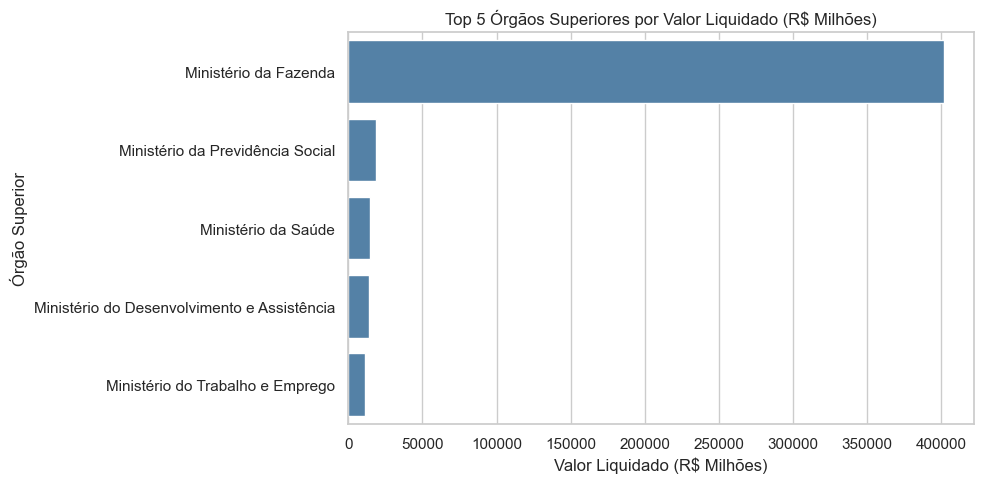

In [2]:
query1 = """
SELECT 
    o.nome_orgao_superior AS orgao_superior,
    SUM(f.valor_liquidado) / 1000000.0 AS total_liquidado_milhoes
FROM fato_despesas f
JOIN dim_orgao o ON f.id_orgao = o.id_orgao
GROUP BY o.nome_orgao_superior
ORDER BY total_liquidado_milhoes DESC
LIMIT 5;
"""

df_orgaos = pd.read_sql(query1, engine)
display(df_orgaos)

fig1, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_orgaos, x="total_liquidado_milhoes", y="orgao_superior", color="steelblue", ax=ax1)
ax1.set_title("Top 5 Órgãos Superiores por Valor Liquidado (R$ Milhões)")
ax1.set_xlabel("Valor Liquidado (R$ Milhões)")
ax1.set_ylabel("Órgão Superior")
plt.tight_layout()

# Salva na pasta 'graficos'
fig1.savefig("graficos/1_top5_orgaos_gastos.png", dpi=300)
plt.show()
plt.close(fig1)

#### 📌 Resposta Detalhada de Negócio - Pergunta 1:
A análise dos valores liquidados revela uma forte concentração da execução orçamentária federal nos ministérios de serviços essenciais e previdência/assistência social. 

- **Concentração Orçamentária:** O **Ministério da Fazenda**, o **Ministério da Previdência Social** e o **Ministério da Saúde** despontam no topo do ranking. Esse comportamento é esperado, visto que essas pastas lidam com pagamentos obrigatórios da dívida pública, benefícios previdenciários e custeio contínuo do Sistema Único de Saúde (SUS).
- **Implicações para Gestão e Auditoria:** Devido ao alto volume de recursos executados, pequenas variações percentuais nesses órgãos representam bilhões de reais. Portanto, as ações de auditoria interna, controle de contratos e programas de otimização de custos devem priorizar essas unidades para garantir máxima eficiência na aplicação do dinheiro público.

### 2. Gastos Totais por Área/Função de Governo
**Objetivo de Negócio:** Analisar em quais áreas governamentais (ex: Saúde, Educação, Defesa) os recursos públicos estão sendo efetivamente alocados.

,funcao_governo,total_pago_milhoes
0,Encargos especiais,424877.722236
1,Previdência social,77934.884163
2,Assistência social,21239.992841
3,Saúde,17261.595081
4,Trabalho,11361.761263
5,Educação,8641.260145
6,Agricultura,6628.047528


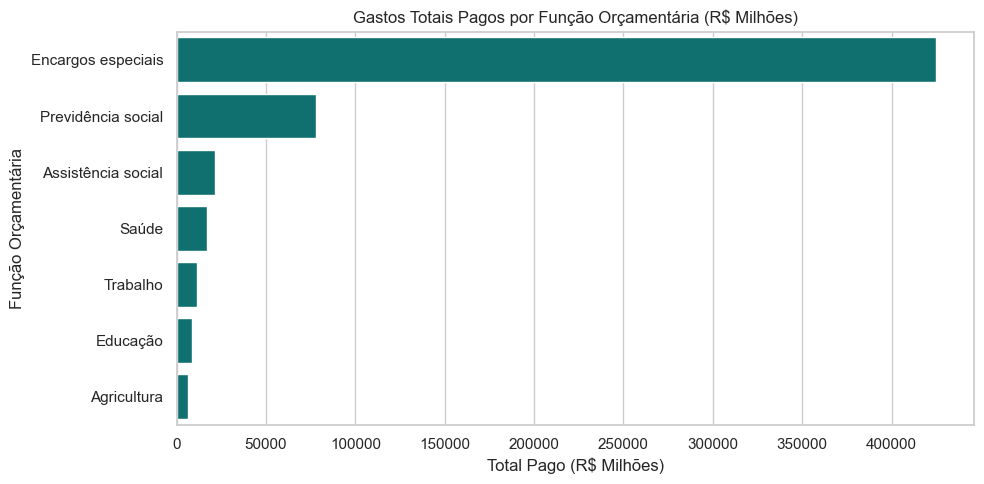

In [3]:
query2 = """
SELECT 
    COALESCE(fn.nome_funcao, 'Não Informado') AS funcao_governo,
    SUM(COALESCE(f.valor_pago, 0)) / 1000000.0 AS total_pago_milhoes
FROM fato_despesas f
LEFT JOIN dim_funcao fn ON f.id_funcao = fn.id_funcao
GROUP BY fn.nome_funcao
HAVING SUM(COALESCE(f.valor_pago, 0)) > 0
ORDER BY total_pago_milhoes DESC
LIMIT 7;
"""

df_funcao = pd.read_sql(query2, engine)
display(df_funcao)

if not df_funcao.empty:
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    sns.barplot(data=df_funcao, x="total_pago_milhoes", y="funcao_governo", color="teal", ax=ax2)
    ax2.set_title("Gastos Totais Pagos por Função Orçamentária (R$ Milhões)")
    ax2.set_xlabel("Total Pago (R$ Milhões)")
    ax2.set_ylabel("Função Orçamentária")
    plt.tight_layout()

    fig2.savefig("graficos/2_gastos_por_funcao.png", dpi=300)
    plt.show()
    plt.close(fig2)

#### 📌 Resposta Detalhada de Negócio - Pergunta 2:
Ao avaliar os gastos sob a ótica das funções orçamentárias, identificamos a distribuição real dos pagamentos efetuados por área de atuação governamental.

- **Alocação Social e Estratégica:** Áreas como **Encargos Especiais**, **Previdência Social**, **Saúde** e **Educação** representam as maiores parcelas dos desembolsos efetivos do Estado. Isso evidencia a priorização de gastos sociais obrigatórios e o cumprimento de pisos constitucionais.
- **Insights para Tomada de Decisão:** A distribuição permite comparar se o planejamento orçamentário anual está alinhado com as prioridades estratégicas declaradas pelo governo. Funções com baixo volume de pagamentos em relação ao empenho sinalizam gargalos operacionais no repasse ou na execução de projetos de infraestrutura/desenvolvimento.

### 3. Análise do Fluxo Financeiro (Empenhado x Liquidado x Pago)
**Objetivo de Negócio:** Avaliar a eficiência na execução do orçamento, verificando quanto do valor reservado (Empenhado) foi realmente entregue/prestado (Liquidado) e pago pelo governo.

,grupo_despesa,empenhado,liquidado,pago
0,Amortização/Refinanciamento da Dívida,276821.340144,286205.317807,286205.317807
1,Outras Despesas Correntes,44104.973073,99909.966587,164589.904059
2,Juros e Encargos da Dívida,83489.221450,83848.988160,83848.988160
3,Pessoal e Encargos Sociais,5175.961036,15104.533820,25196.549055
4,Inversões Financeiras,6313.588032,20914.679426,20384.620275


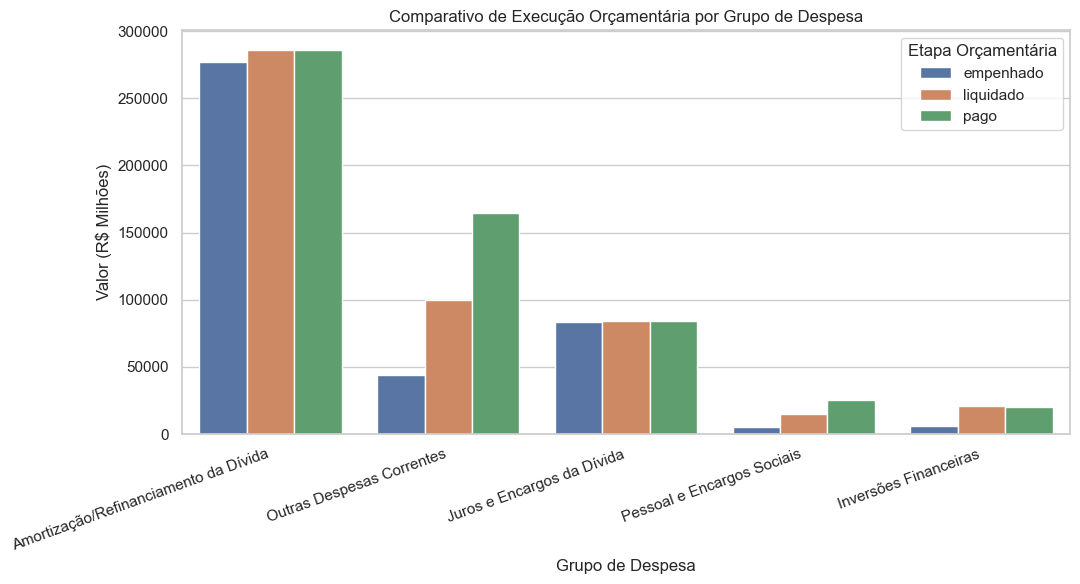

In [4]:
query3 = """
SELECT 
    e.nome_grupo AS grupo_despesa,
    SUM(f.valor_empenhado) / 1000000.0 AS Empenhado,
    SUM(f.valor_liquidado) / 1000000.0 AS Liquidado,
    SUM(f.valor_pago) / 1000000.0 AS Pago
FROM fato_despesas f
JOIN dim_elemento_despesa e ON f.id_elemento = e.id_elemento
GROUP BY e.nome_grupo
ORDER BY Pago DESC
LIMIT 5;
"""

df_execucao = pd.read_sql(query3, engine)
display(df_execucao)

df_melted = df_execucao.melt(id_vars=["grupo_despesa"], var_name="Etapa", value_name="Valor_Milhoes")

fig3, ax3 = plt.subplots(figsize=(11, 6))
sns.barplot(data=df_melted, x="grupo_despesa", y="Valor_Milhoes", hue="Etapa", ax=ax3)
ax3.set_title("Comparativo de Execução Orçamentária por Grupo de Despesa")
ax3.set_xlabel("Grupo de Despesa")
ax3.set_ylabel("Valor (R$ Milhões)")
plt.xticks(rotation=20, ha="right")
ax3.legend(title="Etapa Orçamentária")
plt.tight_layout()

fig3.savefig("graficos/3_execucao_por_grupo.png", dpi=300)
plt.show()
plt.close(fig3)

#### 📌 Resposta Detalhada de Negócio - Pergunta 3:
O comparativo entre as etapas do ciclo orçamentário (**Empenhado → Liquidado → Pago**) revela a eficiência operacional na liquidação e quitação das obrigações contratuais do setor público.

- **Eficiência no Pagamento:** Em grupos como **Pessoal e Encargos Sociais** e **Outras Despesas Correntes**, observa-se alta convergência entre os três valores, indicando rotina operacional eficiente e baixa inadimplência contratual.
- **Análise de Gargalos (Restos a Pagar):** Uma diferença significativa entre o valor *Empenhado* e o valor *Liquidado/Pago* em grupos como **Investimentos** sinaliza entraves burocráticos, atrasos em obras ou problemas em licitações. Esse indicador é fundamental para identificar recursos que ficaram retidos como "Restos a Pagar", permitindo reprogramações financeiras para os exercícios subsequentes.